# NLP Workshop Series  |  Claude Assisted — Notebook 1
# Text Preprocessing & Bag of Words

---

## Welcome to the NLP Workshop Series

This is the first notebook in an eight-part hands-on workshop series that takes you on a complete journey through **Natural Language Processing (NLP)** — from the most basic text representations all the way to modern Large Language Model (LLM) based retrieval systems.

Throughout this series, we will use a single, consistent dataset: **English translations of the Holy Quran**. This rich corpus of classical and modern language gives us an ideal playground for exploring how machines can understand, represent, and search through text.

---

## Workshop Roadmap — All 8 Notebooks

```
╔══════════════════════════════════════════════════════════════════════╗
║              NLP WORKSHOP SERIES — COMPLETE ROADMAP                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  NB01: Text Preprocessing & Bag of Words          ◄── YOU ARE HERE  ║
║  NB02: TF-IDF & Ranked Retrieval                                     ║
║  NB03: N-Grams & Context                                             ║
║  NB04: Word2Vec Embeddings                                           ║
║  NB05: FastText & Subword Embeddings                                 ║
║  NB06: Sentence Embeddings & Semantic Search                         ║
║  NB07: Vector Databases & FAISS                                      ║
║  NB08: RAG & LLM-based Retrieval                                     ║
╚══════════════════════════════════════════════════════════════════════╝
```

Each notebook builds directly on the previous one. By the end of NB08, you will have built a fully functional Retrieval-Augmented Generation (RAG) system from scratch.

---

## This Notebook's Objectives

By the end of this notebook, you will be able to:

1. **Explain** the NLP pipeline and why text must be preprocessed before use
2. **Implement** a complete text preprocessing pipeline in Python (lowercasing, punctuation removal, tokenization, stopword removal, stemming)
3. **Build** a vocabulary from a real corpus
4. **Construct** a Bag of Words (BoW) document-term matrix using scikit-learn
5. **Perform** keyword search and cosine similarity search over a text corpus
6. **Articulate** the fundamental limitations of the Bag of Words model

---

## Historical Context: NLP in the 1990s and 2000s

To appreciate where NLP is today, it helps to understand where it came from.

### The Rule-Based Era (1950s–1980s)
Early NLP systems were entirely hand-crafted. Linguists wrote explicit grammar rules and vocabulary lists. Systems like ELIZA (1966) mimicked conversation through pattern matching, but had no real language understanding.

### The Statistical Revolution (1990s)
The 1990s saw a dramatic shift. Researchers discovered that statistical models trained on large text corpora could outperform hand-crafted rules. Key developments:
- **1991**: The ACL anthology begins tracking NLP research at scale
- **1994**: WordNet, a lexical database, is released
- **1996**: The Bag of Words model becomes standard for document classification
- **1998**: TF-IDF weighting becomes widespread in Information Retrieval
- **1999**: Salton & Buckley's vector space model dominates search engines

### The Machine Learning Era (2000s)
- **2001**: SVMs applied to text classification
- **2003**: Blei et al. introduce Latent Dirichlet Allocation (LDA) for topic modeling
- **2006**: IBM's statistical machine translation systems beat rule-based ones
- **2008**: Sentiment analysis becomes a major subfield

The Bag of Words model, which we study in this notebook, was **the dominant paradigm** for about two decades. Understanding it deeply is essential before moving to neural methods.

---

## Section 1: What is Natural Language Processing?

---

### Definition

**Natural Language Processing (NLP)** is a subfield of Artificial Intelligence concerned with the interaction between computers and human language. It involves developing algorithms and models that enable computers to:
- **Understand** the meaning and structure of text and speech
- **Generate** coherent and contextually appropriate language
- **Transform** language from one form to another (e.g., translation, summarization)

More formally: NLP sits at the intersection of **linguistics**, **computer science**, and **machine learning**.

---

### Real-World Applications

NLP powers technologies you use every day:

| Application | Example |
|---|---|
| Search Engines | Google understanding your query intent |
| Machine Translation | Google Translate, DeepL |
| Virtual Assistants | Siri, Alexa, Google Assistant |
| Sentiment Analysis | Amazon/Netflix product review analysis |
| Spam Detection | Gmail filtering unwanted emails |
| Question Answering | ChatGPT, Gemini, Claude |
| Named Entity Recognition | Extracting names/places from news articles |
| Text Summarization | Automatic news summarization |
| Autocomplete | Smartphone keyboard predictions |

---

### Why is NLP Hard?

Language appears simple to humans but is extraordinarily complex for machines. Here are the core challenges:

**1. Ambiguity**
- *Lexical ambiguity*: "bank" can mean a river bank or a financial institution
- *Syntactic ambiguity*: "I saw the man with a telescope" — who has the telescope?
- *Semantic ambiguity*: "The chicken is ready to eat" — is the chicken hungry, or is it cooked?

**2. Context Dependence**
- "It's cold" means very different things in a weather report vs. a description of someone's personality
- Pronouns and coreference: "The trophy didn't fit in the suitcase because it was too big" — what does "it" refer to?

**3. Language Variation**
- Dialects, slang, informal writing, abbreviations
- Sarcasm and irony: "Oh great, another Monday"
- Domain-specific language: legal text, medical jargon, poetry

**4. World Knowledge**
- Understanding "The Eiffel Tower is in Paris" requires knowing geography
- Implicit references and cultural context

**5. Morphological Complexity**
- "run", "runs", "running", "ran" all refer to the same concept
- In Arabic, a single word can encode what English expresses in a full sentence

The Quran translations we use in this workshop exhibit many of these challenges — poetic language, classical vocabulary, metaphors, and rich contextual meaning — making it an excellent dataset for studying NLP techniques.

---

In [1]:
# Section 1 — Quick demonstration of NLP ambiguity
# This cell illustrates why language understanding is non-trivial

ambiguous_sentences = [
    "I saw the man with a telescope.",
    "The chicken is ready to eat.",
    "She can't bear children.",
    "Time flies like an arrow; fruit flies like a banana.",
    "Visiting relatives can be boring."
]

print("=" * 60)
print("EXAMPLES OF LINGUISTIC AMBIGUITY")
print("(Each sentence has at least 2 valid interpretations)")
print("=" * 60)

for i, sentence in enumerate(ambiguous_sentences, 1):
    print(f"\n{i}. {sentence}")

print("\n" + "=" * 60)
print("A computer must resolve these ambiguities to 'understand' text.")
print("=" * 60)

EXAMPLES OF LINGUISTIC AMBIGUITY
(Each sentence has at least 2 valid interpretations)

1. I saw the man with a telescope.

2. The chicken is ready to eat.

3. She can't bear children.

4. Time flies like an arrow; fruit flies like a banana.

5. Visiting relatives can be boring.

A computer must resolve these ambiguities to 'understand' text.


## Section 2: Loading the Dataset

---

### About the Dataset

We will work with a curated dataset of **English translations of the Holy Quran**. The Quran is one of the most translated texts in human history, making it a unique resource for NLP — we have multiple expert human translations of the exact same source text, allowing fascinating comparisons.

**Dataset details:**
- **6,236 rows** — one per verse
- **18 columns** — Surah (chapter), Verse number, and 16 translation columns
- **16 translators** including Arberry, Pickthall, Yusuf Ali, Maududi, and others

**For this workshop series, we will use the `daryabadi` translation consistently.** This is a classical translation by Abdul Majid Daryabadi, known for its formal and precise English style.

---

In [2]:
# Section 2 - Import libraries and load the dataset
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# Robust path finder: works regardless of which directory Jupyter was launched from
def find_dataset(filename='quran_translations.csv'):
    candidates = [
        os.path.join('..', filename),
        filename,
        os.path.join('..', '..', filename),
        os.path.join(os.getcwd(), '..', filename),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(
        "Could not find '" + filename + "'.\n"
        "Make sure the CSV is in the same folder or one level above this notebook."
    )

csv_path = find_dataset()
df = pd.read_csv(csv_path)

print("Dataset loaded from:", os.path.abspath(csv_path))
print("=" * 50)
print("Shape       :", df.shape[0], "rows x", df.shape[1], "columns")
print("All Columns :", list(df.columns))


Dataset loaded from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\quran_translations.csv
Shape       : 6236 rows x 18 columns
All Columns : ['Surah', 'Verse', 'ahmedali', 'ahmedraza', 'arberry', 'daryabadi', 'hilali', 'itani', 'maududi', 'mubarakpuri', 'pickthall', 'qarai', 'qaribullah', 'sahih', 'sarwar', 'shakir', 'wahiduddin', 'yusufali']


In [3]:
# Section 2 — Preview the first few rows of the full dataframe
# This gives us a sense of the structure before we focus on one column

print("First 3 rows of the dataset:")
print("=" * 80)
# Show only first few columns so the output is readable
preview_cols = ['Surah', 'Verse', 'daryabadi', 'yusufali', 'pickthall']
print(df[preview_cols].head(3).to_string(index=False))

First 3 rows of the dataset:
 Surah  Verse                                              daryabadi                                                       yusufali                                           pickthall
     1      1 In the name of Allah, the Compassionate, the Merciful.            In the name of Allah, Most Gracious, Most Merciful. In the name of Allah, the Beneficent, the Merciful.
     1      2     All praise unto Allah, the Lord of all the worlds. Praise be to Allah, the Cherisher and Sustainer of the worlds;             Praise be to Allah, Lord of the Worlds,
     1      3                       The Compassionate, the Merciful.                                  Most Gracious, Most Merciful;                       The Beneficent, the Merciful.


In [ ]:
# Section 2 — Focus on the daryabadi translation column
# We will use ONLY this column throughout all exercises in this notebook

# Check for missing values in the daryabadi column
null_count = df['sahih'].isnull().sum()
total_verses = len(df)

# Compute average text length (in characters)
df['text_length'] = df['sahih'].str.len()
avg_length = df['text_length'].mean()
min_length = df['text_length'].min()
max_length = df['text_length'].max()

print("=" * 50)
print("DARYABADI COLUMN — BASIC STATISTICS")
print("=" * 50)
print(f"Total verses  : {total_verses}")
print(f"Null values   : {null_count}")
print(f"Avg length    : {avg_length:.1f} characters")
print(f"Min length    : {min_length} characters")
print(f"Max length    : {max_length} characters")

DARYABADI COLUMN — BASIC STATISTICS
Total verses  : 6236
Null values   : 0
Avg length    : 134.5 characters
Min length    : 7 characters
Max length    : 1282 characters


In [5]:
# Section 2 — Display 5 sample verses with their Surah and Verse identifiers
# This helps students get a feel for the text content and style

# Select 5 representative samples spread across the dataset
sample_indices = [0, 100, 500, 1500, 3000]
samples = df.loc[sample_indices, ['Surah', 'Verse', 'daryabadi']]

print("=" * 70)
print("SAMPLE VERSES FROM THE DARYABADI TRANSLATION")
print("=" * 70)

for _, row in samples.iterrows():
    print(f"\nSurah {int(row['Surah'])}, Verse {int(row['Verse'])}:")
    print(f"  {row['daryabadi']}")

print("\n" + "=" * 70)

SAMPLE VERSES FROM THE DARYABADI TRANSLATION

Surah 1, Verse 1:
  In the name of Allah, the Compassionate, the Merciful.

Surah 2, Verse 94:
  Say thou: if for you alone is the abode of the Hereafter with Allah to the exclusion of mankind, then wish for death if ye say sooth.

Surah 4, Verse 8:
  And when those of kin are Present at the division and the orphans and the needy, provide for them thereout, and say unto them a reputable saying.

Surah 11, Verse 28:
  He said: bethink ye, O my people! if I rested upon an evidence from my Lord, and a mercy hath come unto me from Him, and that hath been obscured unto you, Shall we make you adhere to it while ye are averse thereto?

Surah 26, Verse 69:
  And recite unto them the story of Ibrahim.



## Section 3: Text Preprocessing — Theory

---

### Why Raw Text Cannot Be Used Directly

Computers work with numbers. Text, in its raw form, is just a sequence of characters — and characters are meaningless to mathematical algorithms. Before we can apply any machine learning or information retrieval technique, we must convert text into a **structured numerical representation**.

But before we even get to numbers, we need to **clean and normalize** the text. Consider these two phrases:
- `"Allah is Most Merciful"`
- `"allah is most merciful."`

To a human, these are identical in meaning. To a computer without preprocessing, they are completely different strings. The same word `"Merciful"` and `"merciful"` would be treated as two different vocabulary items.

Preprocessing solves this by standardizing text before analysis.

---

### The Standard NLP Preprocessing Pipeline

```
Raw Text
   │
   ▼
[ Step 1: Lowercasing ]         → Normalize letter case
   │
   ▼
[ Step 2: Punctuation Removal ] → Remove non-alphabetic noise
   │
   ▼
[ Step 3: Tokenization ]        → Split into individual words (tokens)
   │
   ▼
[ Step 4: Stopword Removal ]    → Remove high-frequency meaningless words
   │
   ▼
[ Step 5: Stemming/Lemmatization ] → Reduce words to root form
   │
   ▼
Processed Tokens
```

Let's understand each step in depth:

---

### Step 1: Lowercasing

**What it does:** Converts all characters to lowercase.

**Why it matters:** Without lowercasing, `"God"`, `"god"`, and `"GOD"` would be three separate vocabulary items. In a frequency count, each would appear to occur less often than they actually do. Lowercasing merges these into one token.

**Example:**
```
Before: "In the Name of Allah, the Most Beneficent"
After:  "in the name of allah, the most beneficent"
```

**Caveat:** For some tasks (e.g., Named Entity Recognition), case carries meaning. But for BoW and search, lowercasing is almost always beneficial.

---

### Step 2: Punctuation Removal

**What it does:** Removes characters that are not letters or numbers (commas, periods, semicolons, brackets, etc.).

**Why it matters:** Punctuation does not carry meaning in BoW. The word `"merciful"` and `"merciful,"` should be treated identically. Without removing punctuation, they would be different tokens.

**We use a regular expression (regex):** `re.sub(r'[^a-zA-Z\s]', '', text)` — this keeps only alphabetic characters and spaces.

**Example:**
```
Before: "in the name of allah, the most beneficent"
After:  "in the name of allah  the most beneficent"
```

---

### Step 3: Tokenization

**What it does:** Splits a string of text into a list of individual tokens (usually words).

**Why it matters:** A string is a sequence of characters. We need a sequence of **word units** to count, compare, and model. Tokenization is the bridge between raw text and structured data.

**We use NLTK's `word_tokenize`**, which is smarter than simple splitting on spaces. It correctly handles contractions, abbreviations, and punctuation edge cases.

**Example:**
```
Before: "in the name of allah the most beneficent"
After:  ['in', 'the', 'name', 'of', 'allah', 'the', 'most', 'beneficent']
```

---

### Step 4: Stopword Removal

**What it does:** Removes extremely common words ("the", "is", "in", "of", "and", "a", ...) that appear in almost every document.

**Why it matters:** If every document contains the word "the" thousands of times, then "the" carries zero discriminative power. Keeping it wastes computational resources and adds noise. Removing it makes the vocabulary more meaningful.

**NLTK provides a standard English stopword list** of ~179 words. You can also customize it — for Islamic text, you might want to keep words like "not" which change the entire meaning of a sentence.

**Example:**
```
Before: ['in', 'the', 'name', 'of', 'allah', 'the', 'most', 'beneficent']
After:  ['name', 'allah', 'beneficent']
```

Notice how "in", "the", "of", "most" were removed as stopwords.

---


> **Design Warning — Stopwords and Negation**
>
> Removing stopwords is almost always beneficial — but it is a **design decision** with a known failure mode.
> The word **`"not"`** is on the standard English stopword list. This means:
>
> | Sentence | After stopword removal | Meaning preserved? |
> |---|---|---|
> | `"this book is not bad"` | `"book bad"` | NO — double negative lost |
> | `"this book is not good"` | `"book good"` | NO — negation lost |
>
> Both sentences reduce to nearly the same tokens despite having **opposite sentiment**.
> We demonstrate this failure in Section 10.
>
> **Rule of thumb:** for tasks where negation matters, either keep `"not"` in your vocabulary
> or move beyond BoW entirely (N-grams, embeddings).

### Step 5: Stemming

**What it does:** Reduces a word to its root/base form by chopping off suffixes.

**Why it matters:** "mercy", "merciful", "mercifully", "mercifulness" all relate to the same concept. Without stemming, a search for "mercy" would miss verses containing "merciful".

**We use Porter Stemmer** (NLTK) — a rule-based algorithm developed by Martin Porter in 1980. It applies a series of suffix-stripping rules.

**Example:**
```
Before: ['name', 'allah', 'beneficent']
After:  ['name', 'allah', 'beneficent']  ← some words don't change

'merciful'  → 'merci'
'believing'  → 'believ'
'prayers'    → 'prayer'
'righteous'  → 'righteous'
```

**Note:** Stemmer outputs are not always real English words — they are root *stems*. This is fine for matching purposes.

**Alternative: Lemmatization** — reduces words to their dictionary base form (e.g., "running" → "run"). More accurate but slower.

---

## Section 4: Preprocessing Implementation

---

Now we implement the complete preprocessing pipeline step by step. We will show **before and after** outputs at each stage using a single example verse, then apply the full pipeline to the entire corpus.

---

In [6]:
# Section 4 — Install and import all required NLP libraries
# NLTK is the Natural Language Toolkit — the standard Python NLP library

import nltk
import re
import string

# Download required NLTK data packages
# punkt       — tokenizer models
# stopwords   — English stopword list
# punkt_tab   — updated tokenizer data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

print("All libraries imported successfully.")
print(f"NLTK version: {nltk.__version__}")

# Load English stopwords
english_stopwords = set(stopwords.words('english'))
print(f"Number of English stopwords: {len(english_stopwords)}")
print(f"Sample stopwords: {sorted(list(english_stopwords))[:15]}")

All libraries imported successfully.
NLTK version: 3.9.4
Number of English stopwords: 198
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [7]:
# Section 4 — Choose a sample verse to demonstrate preprocessing step-by-step
# We pick a verse that is long enough to show meaningful changes at each step

# Let's use Surah 2, Verse 255 (Ayat al-Kursi) — one of the most famous verses
sample_verse_row = df[(df['Surah'] == 2) & (df['Verse'] == 255)]

if len(sample_verse_row) > 0:
    sample_verse = sample_verse_row['daryabadi'].values[0]
else:
    # Fallback to a known good verse if the above doesn't exist
    sample_verse = df.iloc[300]['daryabadi']

print("=" * 70)
print("ORIGINAL VERSE (Raw Text)")
print("=" * 70)
print(f"\n{sample_verse}")
print(f"\nLength: {len(sample_verse)} characters")

ORIGINAL VERSE (Raw Text)

Allah! There is no God but he, the Living, the Sustainer Slumber taketh hold of Him not, nor sleep. His is whatsoever is in the heavens and whatsoever is on the earth. Who is he that shall intercede With Him except with His leave! He knoweth that which was before them and that which shall he after them, and they encompass not aught of His knowledge save that which He willeth. His throne comprehendeth the heavens and the earth, and the guarding of the twain wearieth Him not. And He is the High, the Supreme.

Length: 511 characters


In [8]:
# Section 4 — Step 1: Lowercasing
# Convert all text to lowercase to ensure case-insensitive matching

step1_lower = sample_verse.lower()

print("=" * 70)
print("STEP 1: LOWERCASING")
print("=" * 70)
print("\nBEFORE:")
print(f"  {sample_verse[:120]}...")
print("\nAFTER:")
print(f"  {step1_lower[:120]}...")
print("\nWhat changed: All uppercase letters converted to lowercase.")

STEP 1: LOWERCASING

BEFORE:
  Allah! There is no God but he, the Living, the Sustainer Slumber taketh hold of Him not, nor sleep. His is whatsoever is...

AFTER:
  allah! there is no god but he, the living, the sustainer slumber taketh hold of him not, nor sleep. his is whatsoever is...

What changed: All uppercase letters converted to lowercase.


In [9]:
# Section 4 — Step 2: Punctuation Removal
# Use regex to remove everything that is not a letter or whitespace
# [^a-zA-Z\s] matches any character that is NOT a letter or space

step2_no_punct = re.sub(r'[^a-zA-Z\s]', '', step1_lower)

# Collapse multiple spaces into a single space
step2_no_punct = re.sub(r'\s+', ' ', step2_no_punct).strip()

print("=" * 70)
print("STEP 2: PUNCTUATION REMOVAL")
print("=" * 70)
print("\nBEFORE:")
print(f"  {step1_lower[:120]}...")
print("\nAFTER:")
print(f"  {step2_no_punct[:120]}...")
print("\nWhat changed: Commas, periods, semicolons, hyphens, numbers removed.")

STEP 2: PUNCTUATION REMOVAL

BEFORE:
  allah! there is no god but he, the living, the sustainer slumber taketh hold of him not, nor sleep. his is whatsoever is...

AFTER:
  allah there is no god but he the living the sustainer slumber taketh hold of him not nor sleep his is whatsoever is in t...

What changed: Commas, periods, semicolons, hyphens, numbers removed.


In [10]:
# Section 4 — Step 3: Tokenization
# Split the cleaned string into a list of word tokens using NLTK
# word_tokenize handles edge cases better than simple str.split()

step3_tokens = word_tokenize(step2_no_punct)

print("=" * 70)
print("STEP 3: TOKENIZATION")
print("=" * 70)
print("\nBEFORE (string):")
print(f"  '{step2_no_punct[:100]}...'")
print("\nAFTER (list of tokens):")
print(f"  {step3_tokens[:20]}")
print(f"  ...")
print(f"\nTotal tokens: {len(step3_tokens)}")
print("\nWhat changed: Text string converted to a list of individual word tokens.")

STEP 3: TOKENIZATION

BEFORE (string):
  'allah there is no god but he the living the sustainer slumber taketh hold of him not nor sleep his i...'

AFTER (list of tokens):
  ['allah', 'there', 'is', 'no', 'god', 'but', 'he', 'the', 'living', 'the', 'sustainer', 'slumber', 'taketh', 'hold', 'of', 'him', 'not', 'nor', 'sleep', 'his']
  ...

Total tokens: 95

What changed: Text string converted to a list of individual word tokens.


In [11]:
# Section 4 — Step 4: Stopword Removal
# Filter out tokens that appear in the NLTK English stopwords list
# We also filter out single-character tokens which carry no meaning

step4_no_stop = [token for token in step3_tokens 
                 if token not in english_stopwords and len(token) > 1]

# Identify which words were removed
removed_words = [token for token in step3_tokens if token in english_stopwords]

print("=" * 70)
print("STEP 4: STOPWORD REMOVAL")
print("=" * 70)
print("\nBEFORE:")
print(f"  {step3_tokens[:20]}")
print("\nAFTER:")
print(f"  {step4_no_stop[:20]}")
print(f"\nTokens before: {len(step3_tokens)}")
print(f"Tokens after:  {len(step4_no_stop)}")
print(f"Tokens removed: {len(step3_tokens) - len(step4_no_stop)}")
print(f"\nSample removed stopwords: {list(set(removed_words))[:10]}")

STEP 4: STOPWORD REMOVAL

BEFORE:
  ['allah', 'there', 'is', 'no', 'god', 'but', 'he', 'the', 'living', 'the', 'sustainer', 'slumber', 'taketh', 'hold', 'of', 'him', 'not', 'nor', 'sleep', 'his']

AFTER:
  ['allah', 'god', 'living', 'sustainer', 'slumber', 'taketh', 'hold', 'sleep', 'whatsoever', 'heavens', 'whatsoever', 'earth', 'shall', 'intercede', 'except', 'leave', 'knoweth', 'shall', 'encompass', 'aught']

Tokens before: 95
Tokens after:  32
Tokens removed: 63

Sample removed stopwords: ['that', 'his', 'before', 'with', 'him', 'he', 'in', 'was', 'there', 'and']


In [12]:
# Section 4 — Step 5: Stemming (Optional but informative)
# Porter Stemmer reduces words to their root stem
# This helps match different forms of the same word

stemmer = PorterStemmer()

# WITHOUT stemming (just the cleaned tokens)
no_stem = step4_no_stop

# WITH stemming
with_stem = [stemmer.stem(token) for token in step4_no_stop]

print("=" * 70)
print("STEP 5: STEMMING (Optional)")
print("=" * 70)
print("\nWITHOUT stemming:")
print(f"  {no_stem[:15]}")
print("\nWITH Porter Stemming:")
print(f"  {with_stem[:15]}")

print("\n--- Word-by-word comparison (first 12 tokens) ---")
print(f"{'Original':<20} {'Stemmed':<20}")
print("-" * 40)
for orig, stemmed in zip(no_stem[:12], with_stem[:12]):
    marker = " ◄ changed" if orig != stemmed else ""
    print(f"{orig:<20} {stemmed:<20}{marker}")

STEP 5: STEMMING (Optional)

WITHOUT stemming:
  ['allah', 'god', 'living', 'sustainer', 'slumber', 'taketh', 'hold', 'sleep', 'whatsoever', 'heavens', 'whatsoever', 'earth', 'shall', 'intercede', 'except']

WITH Porter Stemming:
  ['allah', 'god', 'live', 'sustain', 'slumber', 'taketh', 'hold', 'sleep', 'whatsoev', 'heaven', 'whatsoev', 'earth', 'shall', 'interced', 'except']

--- Word-by-word comparison (first 12 tokens) ---
Original             Stemmed             
----------------------------------------
allah                allah               
god                  god                 
living               live                 ◄ changed
sustainer            sustain              ◄ changed
slumber              slumber             
taketh               taketh              
hold                 hold                
sleep                sleep               
whatsoever           whatsoev             ◄ changed
heavens              heaven               ◄ changed
whatsoever           whats

In [13]:
# Section 4 — Illustrate stemming on NLP-relevant words
# Show how stemming normalizes related word forms

demo_words = [
    'mercy', 'merciful', 'mercifully', 'mercifulness',
    'believe', 'believes', 'believed', 'believing', 'believer', 'believers',
    'pray', 'prays', 'prayed', 'praying', 'prayer', 'prayers',
    'righteous', 'righteously', 'righteousness'
]

print("=" * 50)
print("STEMMING EXAMPLES — RELATED WORD GROUPS")
print("=" * 50)
print(f"\n{'Word':<20} {'Stem':<20}")
print("-" * 40)

prev_stem = None
for word in demo_words:
    stem = stemmer.stem(word)
    if prev_stem and stem != prev_stem:
        print("")
    print(f"{word:<20} {stem:<20}")
    prev_stem = stem

STEMMING EXAMPLES — RELATED WORD GROUPS

Word                 Stem                
----------------------------------------
mercy                merci               
merciful             merci               
mercifully           merci               
mercifulness         merci               

believe              believ              
believes             believ              
believed             believ              
believing            believ              
believer             believ              
believers            believ              

pray                 pray                
prays                pray                
prayed               pray                
praying              pray                

prayer               prayer              
prayers              prayer              

righteous            righteou            

righteously          righteous           
righteousness        righteous           


In [14]:
# Section 4 — Define the complete preprocessing function
# This encapsulates all five steps into a single reusable function
# We use stemming=False by default for better human readability

def preprocess_text(text, use_stemming=False):
    """
    Complete NLP preprocessing pipeline.
    
    Steps:
        1. Lowercase
        2. Remove punctuation (regex)
        3. Tokenize (NLTK word_tokenize)
        4. Remove stopwords (NLTK English)
        5. Optional Porter stemming
    
    Args:
        text (str): Raw input text
        use_stemming (bool): Whether to apply Porter stemming
    
    Returns:
        str: Preprocessed text as space-joined tokens
    """
    # Handle None / NaN values
    if pd.isna(text) or text is None:
        return ''
    
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 3: Tokenize
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords and single-character tokens
    tokens = [t for t in tokens if t not in english_stopwords and len(t) > 1]
    
    # Step 5: Optional stemming
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    
    return ' '.join(tokens)

print("preprocess_text() function defined successfully.")
print("\nTest run:")
test_input = "In the Name of Allah, the Most Beneficent, the Most Merciful!"
print(f"  Input:  '{test_input}'")
print(f"  Output: '{preprocess_text(test_input)}'")

preprocess_text() function defined successfully.

Test run:
  Input:  'In the Name of Allah, the Most Beneficent, the Most Merciful!'
  Output: 'name allah beneficent merciful'


In [15]:
# Section 4 — Apply preprocessing to the entire corpus
# This may take a few seconds for 6,236 verses
# We store the result in a new column 'processed'

print("Applying preprocessing to all verses...")
print("(This processes 6,236 verses — may take 10–30 seconds)")
print()

# Apply the preprocessing function to every row in the daryabadi column
df['processed'] = df['daryabadi'].apply(lambda x: preprocess_text(x, use_stemming=False))

print("Preprocessing complete!")
print(f"\nNew column 'processed' added to dataframe.")
print(f"Shape is now: {df.shape}")

Applying preprocessing to all verses...
(This processes 6,236 verses — may take 10–30 seconds)

Preprocessing complete!

New column 'processed' added to dataframe.
Shape is now: (6236, 20)


In [16]:
# Section 4 — Show 5 samples comparing raw vs processed text
# This confirms the pipeline is working correctly

print("=" * 70)
print("PREPROCESSING RESULTS — 5 SAMPLE VERSES")
print("=" * 70)

sample_indices_pp = [0, 50, 200, 1000, 3500]

for idx in sample_indices_pp:
    row = df.iloc[idx]
    print(f"\nSurah {int(row['Surah'])}, Verse {int(row['Verse'])}")
    print(f"  RAW      : {row['daryabadi'][:100]}..." if len(row['daryabadi']) > 100 else f"  RAW      : {row['daryabadi']}")
    print(f"  PROCESSED: {row['processed'][:100]}..." if len(row['processed']) > 100 else f"  PROCESSED: {row['processed']}")

PREPROCESSING RESULTS — 5 SAMPLE VERSES

Surah 1, Verse 1
  RAW      : In the name of Allah, the Compassionate, the Merciful.
  PROCESSED: name allah compassionate merciful

Surah 2, Verse 44
  RAW      : Command ye mankind to piety and forget yourselves, the while ye read the Book! Understand then ye no...
  PROCESSED: command ye mankind piety forget ye read book understand ye

Surah 2, Verse 194
  RAW      : A sacred month is for a sacred month; these sacrednesses are in retaliation. Whosoever then offereth...
  PROCESSED: sacred month sacred month sacrednesses retaliation whosoever offereth violence unto offer violence u...

Surah 7, Verse 47
  RAW      : And when their eyes Will be turned toward the fellows of the Fire, they will say: our Lord! place us...
  PROCESSED: eyes turned toward fellows fire say lord place us wrongdoing people

Surah 31, Verse 32
  RAW      : And when a wave covereth them like awnings, they call upon Allah, making their religion pure for Him...
  PROCESSED

## Section 5: Building the Vocabulary

---

### What is a Vocabulary?

The **vocabulary** (also called a *lexicon*) is the set of all unique words that appear in a corpus. In NLP, the vocabulary defines the **feature space** — every word in the vocabulary is potentially a feature (dimension) in our vector representation.

For the Bag of Words model:
- Each document is represented as a vector of length `|V|` (vocabulary size)
- Each position in the vector corresponds to one word in the vocabulary
- The value at each position is the count (or weight) of that word in the document

A large vocabulary means high-dimensional vectors — one key challenge of BoW.

---

In [17]:
# Section 5 — Build vocabulary from the processed corpus
# We count word frequencies across all 6,236 processed verses

from collections import Counter

# Collect all tokens from all processed verses into one big list
all_tokens = []
for processed_text in df['processed']:
    tokens = processed_text.split()
    all_tokens.extend(tokens)

# Count word frequencies
word_freq = Counter(all_tokens)

# The vocabulary is the set of unique words
vocabulary = set(all_tokens)

print("=" * 50)
print("VOCABULARY STATISTICS")
print("=" * 50)
print(f"Total tokens (with repeats) : {len(all_tokens):,}")
print(f"Unique vocabulary size      : {len(vocabulary):,}")
print(f"Type-Token Ratio            : {len(vocabulary)/len(all_tokens):.4f}")
print(f"\n(Type-Token Ratio = vocabulary diversity measure)")
print(f"(Closer to 1 = more diverse; closer to 0 = more repetitive)")

VOCABULARY STATISTICS
Total tokens (with repeats) : 72,363
Unique vocabulary size      : 6,459
Type-Token Ratio            : 0.0893

(Type-Token Ratio = vocabulary diversity measure)
(Closer to 1 = more diverse; closer to 0 = more repetitive)


In [18]:
# Section 5 — Show the 20 most common words
# These are the most informative words in the Quran corpus (after stopword removal)

top_20_words = word_freq.most_common(20)

print("=" * 40)
print("TOP 20 MOST FREQUENT WORDS")
print("(After preprocessing)")
print("=" * 40)
print(f"\n{'Rank':<6} {'Word':<20} {'Count':<10}")
print("-" * 36)

for rank, (word, count) in enumerate(top_20_words, 1):
    print(f"{rank:<6} {word:<20} {count:<10}")

TOP 20 MOST FREQUENT WORDS
(After preprocessing)

Rank   Word                 Count     
------------------------------------
1      allah                2520      
2      unto                 2162      
3      ye                   1851      
4      shall                1700      
5      verily               1494      
6      thou                 1349      
7      lord                 969       
8      hath                 898       
9      say                  780       
10     said                 769       
11     thee                 612       
12     people               477       
13     day                  464       
14     us                   463       
15     may                  452       
16     believe              401       
17     earth                389       
18     thy                  386       
19     surely               386       
20     sent                 359       


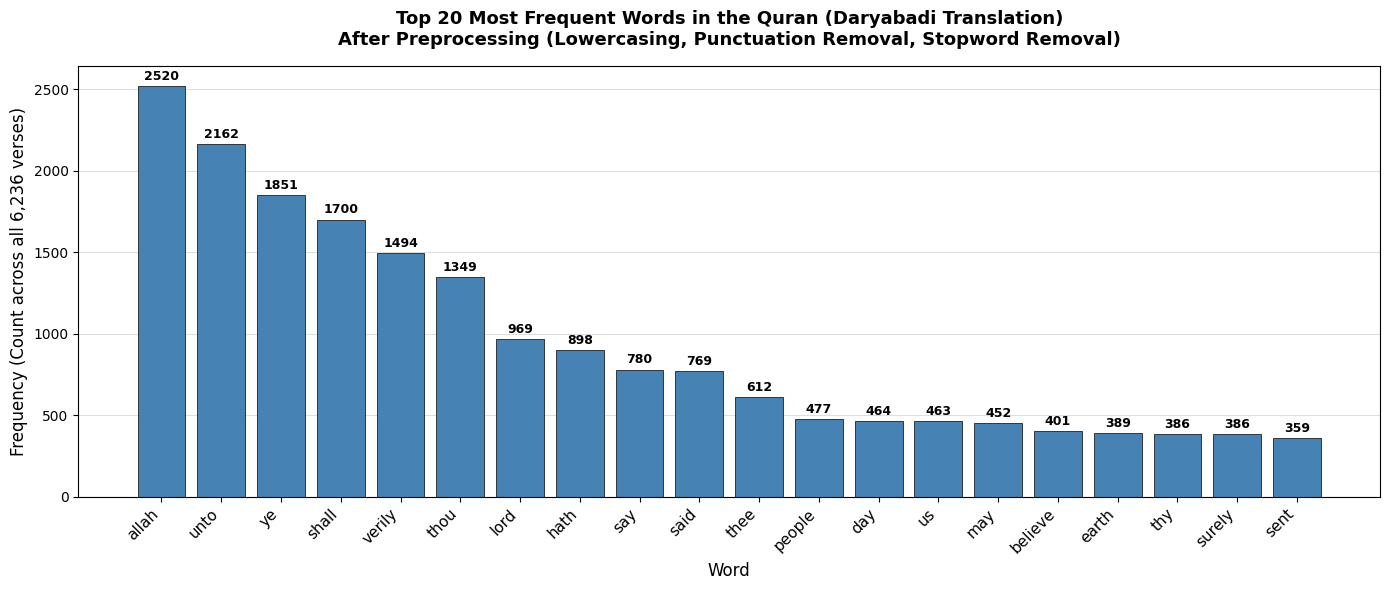

Bar chart saved as 'top20_words.png'


In [19]:
# Section 5 — Visualize top 20 words as a bar chart
# Matplotlib is the standard Python plotting library

import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Extract words and counts
words = [item[0] for item in top_20_words]
counts = [item[1] for item in top_20_words]

# Create the bar chart
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(words, counts, color='steelblue', edgecolor='black', linewidth=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Labels and formatting
ax.set_title('Top 20 Most Frequent Words in the Quran (Daryabadi Translation)\n'
             'After Preprocessing (Lowercasing, Punctuation Removal, Stopword Removal)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Word', fontsize=12)
ax.set_ylabel('Frequency (Count across all 6,236 verses)', fontsize=12)
ax.set_xticklabels(words, rotation=45, ha='right', fontsize=11)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('top20_words.png', dpi=120, bbox_inches='tight')
plt.show()

print("Bar chart saved as 'top20_words.png'")

In [20]:
# Section 5 — Examine vocabulary distribution (Zipf's Law)
# Zipf's Law: word frequency is roughly inversely proportional to rank
# Most words appear very rarely; a few words appear very frequently

# Count how many words appear exactly once (hapax legomena)
hapax = sum(1 for word, count in word_freq.items() if count == 1)
appear_twice = sum(1 for word, count in word_freq.items() if count == 2)
appear_10plus = sum(1 for word, count in word_freq.items() if count >= 10)
appear_100plus = sum(1 for word, count in word_freq.items() if count >= 100)

print("=" * 55)
print("VOCABULARY FREQUENCY DISTRIBUTION (Zipf's Law)")
print("=" * 55)
print(f"\nWords appearing exactly once  : {hapax:,} ({100*hapax/len(vocabulary):.1f}% of vocab)")
print(f"Words appearing exactly twice : {appear_twice:,}")
print(f"Words appearing 10+ times     : {appear_10plus:,}")
print(f"Words appearing 100+ times    : {appear_100plus:,}")
print(f"\nInsight: ~{100*hapax/len(vocabulary):.0f}% of words are rare (appear only once).")
print("This is typical of natural language (Zipf's Law).")
print("Rare words create sparse, noisy BoW vectors.")

VOCABULARY FREQUENCY DISTRIBUTION (Zipf's Law)

Words appearing exactly once  : 2,779 (43.0% of vocab)
Words appearing exactly twice : 969
Words appearing 10+ times     : 1,060
Words appearing 100+ times    : 110

Insight: ~43% of words are rare (appear only once).
This is typical of natural language (Zipf's Law).
Rare words create sparse, noisy BoW vectors.


## Section 6: Bag of Words — Theory

---

### The Core Idea

The **Bag of Words (BoW)** model is one of the simplest and most foundational ways to represent text as numbers. The core idea is:

> **Represent each document as a vector of word counts, ignoring grammar and word order.**

We "put all the words in a bag" — we don't care about their sequence, just which words appear and how many times.

---

### How It Works — Step by Step

**Step 1: Build the vocabulary**
Collect all unique words across all documents. Suppose we have a tiny corpus:
```
Doc 1: "allah is merciful allah is kind"
Doc 2: "allah guides the believers"
Doc 3: "believers seek allah"
```
After preprocessing, the vocabulary is: `{allah, merciful, kind, guides, believers, seek}`

**Step 2: Create a document-term matrix**
Each row = one document. Each column = one vocabulary word. Each cell = count.

```
        allah  merciful  kind  guides  believers  seek
Doc 1:    2       1       1      0        0         0
Doc 2:    1       0       0      1        1         0
Doc 3:    1       0       0      0        1         1
```

**Step 3: Use the vectors**
- Doc 1 is represented as: `[2, 1, 1, 0, 0, 0]`
- Doc 2 is represented as: `[1, 0, 0, 1, 1, 0]`
- Doc 3 is represented as: `[1, 0, 0, 0, 1, 1]`

Now we can do arithmetic! We can compute similarity between documents, classify them, cluster them, etc.

---

### Sparse Vectors — A Key Property

In a real corpus with a vocabulary of 10,000 words, each document vector has 10,000 dimensions. But a typical document contains only 50–200 unique words. So the vector is **mostly zeros**.

```
Vocabulary size = 10,000 words

A verse with 30 unique words:

[0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, ...]
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑
 9,970 zeros              30 non-zero values
                    (only 0.3% of dimensions are non-zero)
```

This sparsity is both a computational challenge (wasted memory for zeros) and a modeling problem (distances become less meaningful in very high dimensions).

---

### Why BoW Was Revolutionary

Despite its simplicity, BoW enabled many breakthroughs:
- **Document classification** (spam vs. not spam) with SVM or Naive Bayes
- **Information retrieval** — matching documents to queries
- **Topic modeling** (LDA)
- **Sentiment analysis** at scale

It was the backbone of early search engines and text classifiers from the mid-1990s through the mid-2010s.

---

### BoW vs. the Alternatives We Will Study

```
Representation      Captures     Captures     Captures     Dense?
                    Word Freq?   Context?     Semantics?
─────────────────────────────────────────────────────────────────
Bag of Words        ✓            ✗            ✗            ✗
TF-IDF (NB02)       ✓ (weighted) ✗            ✗            ✗
N-Grams (NB03)      ✓            Partial      ✗            ✗
Word2Vec (NB04)     ✗            ✓ (local)    ✓            ✓
FastText (NB05)     ✗            ✓            ✓            ✓
Sentence Emb (NB06) ✗            ✓ (global)   ✓            ✓
─────────────────────────────────────────────────────────────────
```

---

## Section 7: Bag of Words Implementation

---

We now build the actual BoW document-term matrix using scikit-learn's `CountVectorizer`. This is the same component used in production NLP systems.

---

In [21]:
# Section 7 — Build the Bag of Words model using scikit-learn CountVectorizer
# CountVectorizer converts a collection of text documents to a document-term matrix

from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse as sp

# Initialize CountVectorizer
# min_df=2 means ignore words that appear in fewer than 2 documents
#          (removes very rare/misspelled words from vocabulary)
vectorizer = CountVectorizer(
    min_df=2,          # minimum document frequency
    max_features=5000  # limit vocab to top 5000 words for efficiency
)

# Fit and transform: build vocabulary AND create document-term matrix
# The input is our list of preprocessed verse strings
bow_matrix = vectorizer.fit_transform(df['processed'])

print("=" * 55)
print("BAG OF WORDS MATRIX — OVERVIEW")
print("=" * 55)
print(f"\nMatrix shape    : {bow_matrix.shape}")
print(f"  Rows          : {bow_matrix.shape[0]} (one per verse)")
print(f"  Columns       : {bow_matrix.shape[1]} (one per vocabulary word)")
print(f"\nMatrix type     : {type(bow_matrix).__name__} (sparse format)")
print(f"Total elements  : {bow_matrix.shape[0] * bow_matrix.shape[1]:,}")
print(f"Non-zero values : {bow_matrix.nnz:,}")
print(f"Sparsity        : {100 * (1 - bow_matrix.nnz / (bow_matrix.shape[0]*bow_matrix.shape[1])):.2f}%")

BAG OF WORDS MATRIX — OVERVIEW

Matrix shape    : (6236, 3596)
  Rows          : 6236 (one per verse)
  Columns       : 3596 (one per vocabulary word)

Matrix type     : csr_matrix (sparse format)
Total elements  : 22,424,656
Non-zero values : 62,736
Sparsity        : 99.72%


In [22]:
# Section 7 — Examine the vocabulary
# get_feature_names_out() returns the list of words, one per column

feature_names = vectorizer.get_feature_names_out()

print("=" * 50)
print("VOCABULARY SAMPLE")
print("=" * 50)
print(f"\nTotal vocabulary size: {len(feature_names)}")

print("\nFirst 30 words (alphabetical):")
print(list(feature_names[:30]))

print("\nLast 30 words:")
print(list(feature_names[-30:]))

# Check if specific keywords are in vocabulary
keywords_to_check = ['allah', 'mercy', 'merciful', 'prayer', 'believer', 'righteous', 'heaven', 'fire']
print("\nKeyword presence check:")
for kw in keywords_to_check:
    present = kw in feature_names
    print(f"  '{kw}': {'YES' if present else 'NO'}")

VOCABULARY SAMPLE

Total vocabulary size: 3596

First 30 words (alphabetical):
['aad', 'abandon', 'abandoned', 'abase', 'abased', 'abated', 'abhor', 'abhorrent', 'abide', 'abidence', 'abider', 'abiders', 'abject', 'abjection', 'abjectness', 'able', 'abode', 'abodes', 'abolisheth', 'abomination', 'abroad', 'absent', 'abstain', 'abstained', 'abundance', 'abundant', 'abyss', 'accept', 'accepted', 'accepteth']

Last 30 words:
['wronged', 'wronger', 'wrongeth', 'wrongfully', 'wrongously', 'wroth', 'wrought', 'ya', 'yahya', 'yajuj', 'yaqub', 'ye', 'yea', 'year', 'years', 'yellow', 'yes', 'yesterday', 'yet', 'yonder', 'young', 'youth', 'youths', 'yunus', 'yusuf', 'zakariyya', 'zaqqum', 'zihar', 'zul', 'zulkifl']

Keyword presence check:
  'allah': YES
  'mercy': YES
  'merciful': YES
  'prayer': YES
  'believer': YES
  'righteous': YES
  'heaven': YES
  'fire': YES


In [37]:
# Section 7 — Inspect the BoW vector for a single verse
# This shows exactly how a verse is represented as a bag of word counts

# Choose a specific verse to inspect
verse_idx = 250  # First verse of the Quran (Al-Fatiha, 1:1)

verse_raw = df.iloc[verse_idx]['daryabadi']
verse_processed = df.iloc[verse_idx]['processed']
verse_vector = bow_matrix[verse_idx]  # Sparse vector for this verse

print("=" * 65)
print(f"VERSE INSPECTION — Surah {int(df.iloc[verse_idx]['Surah'])}, Verse {int(df.iloc[verse_idx]['Verse'])}")
print("=" * 65)
print(f"\nRaw text    : {verse_raw}")
print(f"Processed   : {verse_processed}")
print(f"\nVector shape: {verse_vector.shape}")
print(f"Non-zero    : {verse_vector.nnz} (words present in this verse)")

# Get the non-zero entries: word -> count
nonzero_indices = verse_vector.nonzero()[1]
print("\nWord counts in this verse:")
print(f"{'Word':<20} {'Count':<10}")
print("-" * 30)
for idx in nonzero_indices:
    word = feature_names[idx]
    count = verse_vector[0, idx]
    print(f"{word:<20} {count:<10}")

VERSE INSPECTION — Surah 2, Verse 244

Raw text    : And fight in the way of Allah and know that verily Allah is Hearing, Knowing.
Processed   : fight way allah know verily allah hearing knowing

Vector shape: (1, 3596)
Non-zero    : 7 (words present in this verse)

Word counts in this verse:
Word                 Count     
------------------------------
allah                2         
verily               1         
hearing              1         
know                 1         
way                  1         
knowing              1         
fight                1         


In [24]:
# Section 7 — Top 10 words in a specific verse
# Show the most prominent words in a longer verse

# Find a longer verse to inspect
# Get verse with the most non-zero entries in the BoW matrix
verse_word_counts = np.diff(bow_matrix.tocsr().indptr)  # Number of non-zero per row
richest_verse_idx = np.argmax(verse_word_counts)

rich_verse_raw = df.iloc[richest_verse_idx]['daryabadi']
rich_verse_processed = df.iloc[richest_verse_idx]['processed']
rich_verse_vector = bow_matrix[richest_verse_idx]

print("=" * 65)
print(f"RICHEST VERSE — Surah {int(df.iloc[richest_verse_idx]['Surah'])}, Verse {int(df.iloc[richest_verse_idx]['Verse'])}")
print(f"(Most words in vocabulary — {verse_word_counts[richest_verse_idx]} unique terms)")
print("=" * 65)
print(f"\nRaw text (first 200 chars): {rich_verse_raw[:200]}...")

# Get top 10 words by count
nonzero_indices_rich = rich_verse_vector.nonzero()[1]
word_count_pairs = [(feature_names[i], rich_verse_vector[0, i]) for i in nonzero_indices_rich]
word_count_pairs_sorted = sorted(word_count_pairs, key=lambda x: x[1], reverse=True)

print("\nTop 10 words in this verse:")
print(f"{'Rank':<6} {'Word':<20} {'Count':<10}")
print("-" * 36)
for rank, (word, count) in enumerate(word_count_pairs_sorted[:10], 1):
    print(f"{rank:<6} {word:<20} {count:<10}")

RICHEST VERSE — Surah 2, Verse 282
(Most words in vocabulary — 59 unique terms)

Raw text (first 200 chars): O ye who believe! when ye deal, one with anot her, in lending for a term named, write it down, and let a scribe write it down justly between you, and let not the scribe refuse to write according as Al...

Top 10 words in this verse:
Rank   Word                 Count     
------------------------------------
1      ye                   8         
2      let                  8         
3      allah                6         
4      write                5         
5      witnesses            4         
6      one                  4         
7      thereof              3         
8      scribe               3         
9      shall                2         
10     call                 2         


## Section 8: Exact Keyword Search

---

### What is Keyword Search?

The simplest form of text retrieval is **exact keyword matching**: scan every document and return those that contain the query word. This is the approach used by `Ctrl+F` in a text editor, and early search engines.

**Procedure:**
1. Take a query word (e.g., "mercy")
2. Scan through every verse in the dataset
3. Return all verses where the query word appears as a substring

While simple, this approach has significant limitations — which we will explore after the demonstration.

---

In [25]:
# Section 8 — Exact keyword search function
# Searches the raw (not preprocessed) daryabadi text for an exact word match

def exact_keyword_search(query, dataframe, text_column='daryabadi', top_n=10):
    """
    Search for an exact keyword in a text column using case-insensitive matching.
    
    Args:
        query (str): The keyword to search for
        dataframe (pd.DataFrame): The dataset to search
        text_column (str): Column to search in
        top_n (int): Maximum number of results to return
    
    Returns:
        pd.DataFrame: Matching rows with Surah, Verse, and text
    """
    # Use str.contains with case=False for case-insensitive search
    # na=False handles any NaN values gracefully
    mask = dataframe[text_column].str.contains(
        r'\b' + re.escape(query) + r'\b',  # \b = word boundary (whole word match)
        case=False, 
        na=False, 
        regex=True
    )
    
    results = dataframe[mask][['Surah', 'Verse', text_column]].head(top_n)
    return results, mask.sum()

print("exact_keyword_search() function defined.")

exact_keyword_search() function defined.


In [26]:
# Section 8 — Run exact search for the word "mercy"
# This returns all verses containing the exact word "mercy"

query = "mercy"
results, total_matches = exact_keyword_search(query, df, top_n=10)

print("=" * 70)
print(f"EXACT KEYWORD SEARCH: '{query}'")
print("=" * 70)
print(f"Total matches found: {total_matches} verses")
print(f"Showing top 10:")
print()

for i, (_, row) in enumerate(results.iterrows(), 1):
    print(f"{i}. Surah {int(row['Surah'])}, Verse {int(row['Verse'])}")
    # Highlight the query word in the output
    text = row['daryabadi']
    # Wrap the found word in brackets for emphasis
    highlighted = re.sub(f'({re.escape(query)})', r'[\1]', text, flags=re.IGNORECASE)
    print(f"   {highlighted[:150]}")
    print()

EXACT KEYWORD SEARCH: 'mercy'
Total matches found: 140 verses
Showing top 10:

1. Surah 2, Verse 64
   Then ye turned away there after; so had not the grace of Allah been unto you and His [mercy], ye had surely become of the losers.

2. Surah 2, Verse 105
   Fain would they who disbelieve, be they of the people of the Book or of the associators, that naught of good should be sent down unto you from Your Lo

3. Surah 2, Verse 157
   These! on them shall be benedictions from their Lord and His [mercy], and these! they are the rightly guided.

4. Surah 2, Verse 178
   O O Ye who believe! prescribed unto you is retaliation for the slain; the free for the free, and a bondsman for a bondsman, and a woman for a woman; y

5. Surah 2, Verse 218
   Verily those who have believed and those who have emigrated and have striven hard in the way of Allah, all these shall hope for the [mercy] of Allah, 

6. Surah 2, Verse 286
   Allah tasketh not a soul except according to its capacity. For it shall be

In [27]:
# Section 8 — Demonstrate keyword search limitations
# Show that exact search misses related words

related_words = ['mercy', 'merciful', 'mercies', 'compassion', 'compassionate', 
                 'kindness', 'benevolent', 'gracious', 'forgiveness']

print("=" * 55)
print("KEYWORD SEARCH — RELATED WORD COVERAGE")
print("(Searching for words related to 'mercy')")
print("=" * 55)
print(f"\n{'Query Word':<20} {'Matches':<10}")
print("-" * 30)

for word in related_words:
    _, count = exact_keyword_search(word, df)
    print(f"{word:<20} {count:<10}")

print("\nObservation: Each form of the word requires a separate search.")
print("A user searching for 'mercy' would MISS all verses with 'merciful'.")
print("This is a fundamental limitation of exact keyword search.")

KEYWORD SEARCH — RELATED WORD COVERAGE
(Searching for words related to 'mercy')

Query Word           Matches   
------------------------------
mercy                140       
merciful             119       
mercies              0         
compassion           1         
compassionate        52        
kindness             11        
benevolent           0         
gracious             6         
forgiveness          64        

Observation: Each form of the word requires a separate search.
A user searching for 'mercy' would MISS all verses with 'merciful'.
This is a fundamental limitation of exact keyword search.


## Section 9: BoW Cosine Similarity Search

---

### Beyond Exact Match: Similarity-Based Retrieval

Exact keyword search is brittle — a query must contain the exact same word as the document. A smarter approach is **similarity search**: represent both the query and all documents as vectors, then return the documents whose vectors are most similar to the query vector.

### Cosine Similarity

The most common similarity measure in NLP is **cosine similarity**. It measures the angle between two vectors, regardless of their magnitude.

```
         A · B
cos(θ) = ─────────
         ‖A‖ × ‖B‖
```

- Value range: 0 to 1 (for non-negative count vectors)
- **1** = identical direction (same words in same proportions)
- **0** = no shared words at all

**Why cosine rather than Euclidean distance?** Cosine similarity is length-normalized — a short verse and a long verse that discuss the same topics will have a high cosine similarity, even if their raw word counts differ greatly.

### How BoW Search Works

```
1. Vectorize the query using the SAME CountVectorizer that built the matrix
2. Compute cosine similarity between query vector and all verse vectors
3. Sort verses by similarity score (descending)
4. Return top-k most similar verses
```

---

In [28]:
# Section 9 — Build the cosine similarity search function
# Uses the CountVectorizer and BoW matrix we built in Section 7

from sklearn.metrics.pairwise import cosine_similarity

def bow_similarity_search(query, vectorizer, bow_matrix, dataframe, top_k=5):
    """
    Search for the most similar verses to a query using BoW + cosine similarity.
    
    Steps:
        1. Preprocess the query using same pipeline as the corpus
        2. Vectorize query using the fitted CountVectorizer
        3. Compute cosine similarity with all document vectors
        4. Return top_k most similar verses
    
    Args:
        query (str): Natural language query
        vectorizer: Fitted CountVectorizer
        bow_matrix: Document-term matrix (sparse)
        dataframe (pd.DataFrame): Original dataset
        top_k (int): Number of results to return
    
    Returns:
        list of tuples: (surah, verse, text, similarity_score)
    """
    # Step 1: Preprocess the query exactly like we preprocessed the corpus
    processed_query = preprocess_text(query, use_stemming=False)
    print(f"  Query preprocessed: '{processed_query}'")
    
    # Step 2: Vectorize query using the FITTED vectorizer (not fit again!)
    # transform() uses the existing vocabulary; unknown words are ignored
    query_vector = vectorizer.transform([processed_query])
    print(f"  Query vector shape: {query_vector.shape}, non-zeros: {query_vector.nnz}")
    
    # Step 3: Compute cosine similarity between query and all verses
    # cosine_similarity returns a (1 x num_docs) matrix
    similarities = cosine_similarity(query_vector, bow_matrix).flatten()
    
    # Step 4: Get indices of top_k most similar verses
    top_indices = similarities.argsort()[::-1][:top_k]
    
    # Build results list
    results = []
    for idx in top_indices:
        results.append((
            int(dataframe.iloc[idx]['Surah']),
            int(dataframe.iloc[idx]['Verse']),
            dataframe.iloc[idx]['daryabadi'],
            similarities[idx]
        ))
    
    return results

print("bow_similarity_search() function defined.")

bow_similarity_search() function defined.


In [38]:
# Section 9 — Run BoW similarity search for "allah is merciful"
# Note: this is a phrase — BoW ignores word order and treats it as a bag of words

query = "qualtieis of a good believer"

print("=" * 65)
print(f"BOW COSINE SIMILARITY SEARCH")
print(f"Query: '{query}'")
print("=" * 65)
print()

results = bow_similarity_search(query, vectorizer, bow_matrix, df, top_k=5)

print()
print("TOP 5 MOST SIMILAR VERSES:")
print("-" * 65)

for rank, (surah, verse, text, score) in enumerate(results, 1):
    print(f"\nRank {rank} | Surah {surah}, Verse {verse} | Similarity: {score:.4f}")
    print(f"  {text[:180]}{'...' if len(text) > 180 else ''}")

BOW COSINE SIMILARITY SEARCH
Query: 'qualtieis of a good believer'

  Query preprocessed: 'qualtieis good believer'
  Query vector shape: (1, 3596), non-zeros: 2

TOP 5 MOST SIMILAR VERSES:
-----------------------------------------------------------------

Rank 1 | Surah 92, Verse 9 | Similarity: 0.5000
  And who belieth the Good,

Rank 2 | Surah 92, Verse 6 | Similarity: 0.5000
  And testifieth to the Good,

Rank 3 | Surah 54, Verse 55 | Similarity: 0.4082
  In a good seat, near a Sovereign Omnipotent.

Rank 4 | Surah 70, Verse 21 | Similarity: 0.4082
  And when good toucheth him he is begrudging.

Rank 5 | Surah 83, Verse 20 | Similarity: 0.3536
  A record of good deeds written.


  Query preprocessed: 'allah merciful'
  Query vector shape: (1, 3596), non-zeros: 2


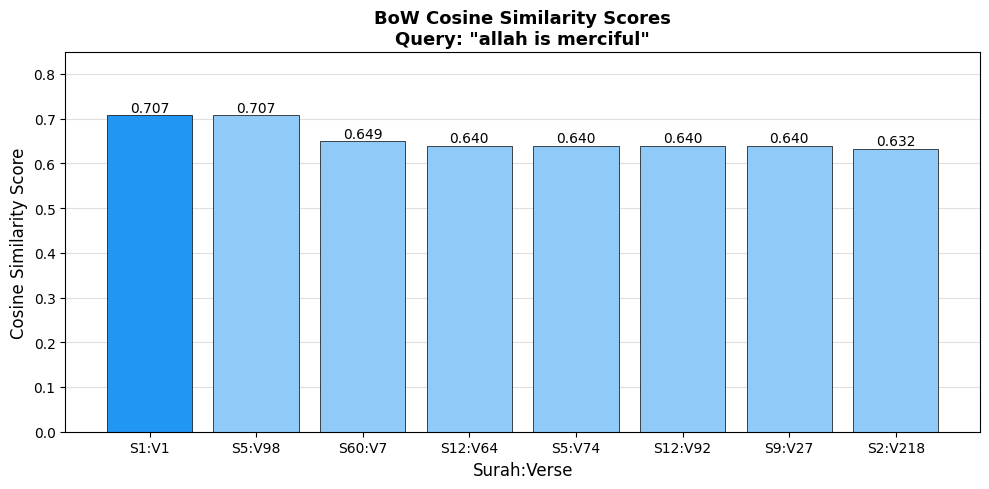

In [30]:
# Section 9 — Visualize similarity scores of top results
# A simple bar chart showing the ranking by similarity score

# Run search again to get fresh results for plotting
query_plot = "allah is merciful"
results_plot = bow_similarity_search(query_plot, vectorizer, bow_matrix, df, top_k=8)

labels = [f"S{r[0]}:V{r[1]}" for r in results_plot]
scores = [r[3] for r in results_plot]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(labels))]
bars = ax.bar(labels, scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_title(f'BoW Cosine Similarity Scores\nQuery: "{query_plot}"',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Surah:Verse', fontsize=12)
ax.set_ylabel('Cosine Similarity Score', fontsize=12)
ax.set_ylim(0, max(scores) * 1.2)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Section 10: Limitations of the Bag of Words Model

---

This is perhaps the **most important section** of this notebook. Understanding what BoW *cannot* do is the primary motivation for every technique we study in Notebooks 2 through 8.

---

### Limitation 1: No Semantics

BoW has absolutely no understanding of **meaning**. It treats words as arbitrary symbols. The words "mercy" and "kindness" are as unrelated to BoW as "mercy" and "elephant" — they are simply different columns in the matrix.

A query for "kindness" will **fail** to retrieve verses about "mercy" or "compassion" even though they describe the same divine attribute.

**The fix:** Word embeddings (Word2Vec, FastText — NB04, NB05) encode semantic relationships.

---

### Limitation 2: No Context

BoW ignores word order entirely. The sentences:
- "Allah forgives the believers" 
- "The believers forgive Allah"

...produce **identical BoW vectors** despite having opposite meanings.

**The fix:** N-gram models (NB03), and transformer-based models that understand context globally.

---

### Limitation 3: Sparse, High-Dimensional Vectors

With a vocabulary of 5,000+ words, each verse is a 5,000-dimensional vector that is 99%+ zeros. This causes:
- High memory usage (even with sparse matrix storage)
- Poor generalization in machine learning
- The **curse of dimensionality** — distances become less meaningful

**The fix:** Dense embeddings (100–300 dimensions with Word2Vec, rather than 5,000).

---

### Limitation 4: Exact Word Dependence

Even with stemming, BoW fails when synonyms are used. If a document uses "compassionate" and the query uses "kind", BoW gives a similarity of 0 — no shared words at all.

---

### Limitation 5: Equal Weight to All Words

BoW counts all words equally. A word appearing once in a verse gets the same *type* of treatment as a word that defines the verse's theme. Common thematic words can dominate. 

**The fix:** TF-IDF weighting (NB02) gives higher weight to words that are distinctive.

---

In [31]:
# Section 10 — FAILURE DEMONSTRATION 1: Semantic gap
# Query with 'kindness' — should retrieve mercy/compassion verses but fails
# This is the most important failure mode to demonstrate

print("=" * 65)
print("FAILURE DEMO 1: SEMANTIC GAP")
print("Query: 'kindness'")
print("Expected: Should find verses about mercy, compassion, divine grace")
print("=" * 65)
print()

failing_query = "kindness"
processed_failing_query = preprocess_text(failing_query)
print(f"Preprocessed query: '{processed_failing_query}'")

# Check if 'kindness' is in the BoW vocabulary
if processed_failing_query in vectorizer.vocabulary_:
    print(f"'kindness' IS in the vocabulary")
else:
    print(f"'kindness' is NOT in the vocabulary (min_df filtered it out)")

print()

# Run the search
failing_results = bow_similarity_search(failing_query, vectorizer, bow_matrix, df, top_k=5)

print()
print("RESULTS — Top 5 verses returned:")
print("-" * 65)

if all(score == 0.0 for _, _, _, score in failing_results):
    print("\n*** ALL SIMILARITY SCORES ARE 0.000 ***")
    print("The BoW model found NO matching verses!")
    print("It cannot recognize that 'kindness' is semantically related to")
    print("'mercy', 'merciful', 'compassion', or 'gracious'.")
else:
    for rank, (surah, verse, text, score) in enumerate(failing_results, 1):
        print(f"\nRank {rank} | Surah {surah}, Verse {verse} | Similarity: {score:.4f}")
        print(f"  {text[:160]}")

FAILURE DEMO 1: SEMANTIC GAP
Query: 'kindness'
Expected: Should find verses about mercy, compassion, divine grace

Preprocessed query: 'kindness'
'kindness' IS in the vocabulary

  Query preprocessed: 'kindness'
  Query vector shape: (1, 3596), non-zeros: 1

RESULTS — Top 5 verses returned:
-----------------------------------------------------------------

Rank 1 | Surah 55, Verse 60 | Similarity: 0.7071
  Shall the recompense of kindness be aught save kindness?

Rank 2 | Surah 4, Verse 62 | Similarity: 0.2887
  How then, when some ill befalleth them because of that which their hands have sent forth and then they come to thee swearing by Allah: we meant naught save kind

Rank 3 | Surah 18, Verse 86 | Similarity: 0.2500
  Until when he reached the setting-place of the sun, he perceived it setting in a miry spring, and he found beside it a nation. We said: Zul Qarnian! either chas

Rank 4 | Surah 4, Verse 114 | Similarity: 0.2294
  No good is there in much of their whispers except in his

In [32]:
# Section 10 — FAILURE DEMO 2: No context / word order blindness
# Show that BoW gives same vector for word-reversed sentences

from sklearn.metrics.pairwise import cosine_similarity

# Two sentences with same words but opposite meanings
sent_a = "this book is not bad"
sent_b = "this book is not good"
sent_c = "fire punishes the disbelievers"  # completely different meaning


# Preprocess all three
proc_a = preprocess_text(sent_a)
proc_b = preprocess_text(sent_b)
proc_c = preprocess_text(sent_c)

# Vectorize
vec_a = vectorizer.transform([proc_a])
vec_b = vectorizer.transform([proc_b])
vec_c = vectorizer.transform([proc_c])

# Compute similarities
sim_ab = cosine_similarity(vec_a, vec_b)[0][0]
sim_ac = cosine_similarity(vec_a, vec_c)[0][0]
sim_bc = cosine_similarity(vec_b, vec_c)[0][0]

print("=" * 65)
print("FAILURE DEMO 2: WORD ORDER BLINDNESS")
print("=" * 65)
print(f"\nSentence A: '{sent_a}'")
print(f"  Preprocessed: '{proc_a}'")
print(f"\nSentence B: '{sent_b}'")
print(f"  Preprocessed: '{proc_b}'")
print(f"\nSentence C: '{sent_c}'")
print(f"  Preprocessed: '{proc_c}'")

print(f"\n{'Pair':<35} {'Cosine Similarity':<20} {'Observation'}")
print("-" * 75)
print(f"{'A vs B (same words, reversed)':<35} {sim_ab:<20.4f} {'SAME MEANING TO BOW!'}")
print(f"{'A vs C (completely different)':<35} {sim_ac:<20.4f} {'Different (as expected)'}")
print(f"{'B vs C (completely different)':<35} {sim_bc:<20.4f} {'Different (as expected)'}")

print("\n*** PROBLEM: A and B have IDENTICAL BoW vectors but opposite meanings! ***")

FAILURE DEMO 2: WORD ORDER BLINDNESS

Sentence A: 'this book is not bad'
  Preprocessed: 'book bad'

Sentence B: 'this book is not good'
  Preprocessed: 'book good'

Sentence C: 'fire punishes the disbelievers'
  Preprocessed: 'fire punishes disbelievers'

Pair                                Cosine Similarity    Observation
---------------------------------------------------------------------------
A vs B (same words, reversed)       0.5000               SAME MEANING TO BOW!
A vs C (completely different)       0.0000               Different (as expected)
B vs C (completely different)       0.0000               Different (as expected)

*** PROBLEM: A and B have IDENTICAL BoW vectors but opposite meanings! ***


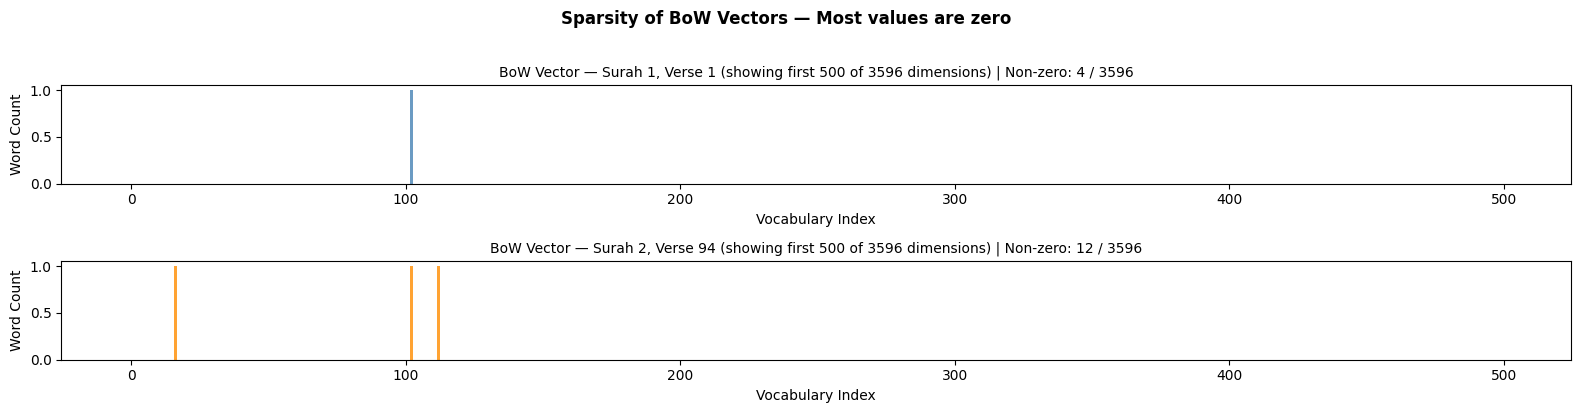


Verse 1 sparsity: 99.9% zeros
Verse 2 sparsity: 99.7% zeros


In [33]:
# Section 10 — FAILURE DEMO 3: Sparsity comparison
# Visualize the sparse nature of BoW vectors for two verses

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Get BoW vectors for two verses
idx1, idx2 = 0, 100
vec1 = bow_matrix[idx1].toarray().flatten()
vec2 = bow_matrix[idx2].toarray().flatten()

fig, axes = plt.subplots(2, 1, figsize=(16, 4))

for ax, vec, idx, color in zip(axes, [vec1, vec2], [idx1, idx2], ['steelblue', 'darkorange']):
    row = df.iloc[idx]
    # Show first 500 dimensions for readability
    ax.bar(range(500), vec[:500], color=color, alpha=0.8, width=1)
    ax.set_title(f"BoW Vector — Surah {int(row['Surah'])}, Verse {int(row['Verse'])} "
                 f"(showing first 500 of {len(vec)} dimensions) | "
                 f"Non-zero: {(vec > 0).sum()} / {len(vec)}",
                 fontsize=10)
    ax.set_ylabel('Word Count')
    ax.set_xlabel('Vocabulary Index')

plt.suptitle('Sparsity of BoW Vectors — Most values are zero',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nVerse 1 sparsity: {100*(1-(vec1>0).sum()/len(vec1)):.1f}% zeros")
print(f"Verse 2 sparsity: {100*(1-(vec2>0).sum()/len(vec2)):.1f}% zeros")

In [34]:
# Section 10 — Summary of BoW limitations
# Structured comparison to motivate the next notebook

print("=" * 65)
print("SUMMARY: LIMITATIONS OF BAG OF WORDS")
print("=" * 65)

limitations = [
    ("No Semantics",
     "'kindness' and 'mercy' are unrelated in BoW space",
     "Word2Vec / Sentence Embeddings (NB04, NB06)"),

    ("No Word Order / Negation",
     "'not bad' == 'not good' after stopword removal",
     "N-Grams (NB03), Transformers (NB06-08)"),

    ("Sparse Vectors",
     "5000-dim vectors that are 99%+ zeros",
     "Dense embeddings (NB04-06)"),

    ("Equal Word Weighting",
     "Common thematic words dominate similarity",
     "TF-IDF (NB02)"),

    ("Exact Word Dependence",
     "Synonyms not handled without extra effort",
     "Word2Vec / Semantic Search (NB04, NB06)")
]

print(f"{'Limitation':<28} {'Example Problem':<42} {'Solution (Notebook)'}")
print("-" * 95)
for name, example, solution in limitations:
    print(f"{name:<28} {example:<42} {solution}")

print()
print("=" * 65)
print("NEXT STEP:")
print("TF-IDF (Term Frequency - Inverse Document Frequency) addresses")
print("the equal weighting problem. It gives higher scores to words")
print("that are important in a document but rare across the corpus.")
print()
print("This motivates us to explore TF-IDF in the next notebook.")
print("=" * 65)


SUMMARY: LIMITATIONS OF BAG OF WORDS
Limitation                   Example Problem                            Solution (Notebook)
-----------------------------------------------------------------------------------------------
No Semantics                 'kindness' and 'mercy' are unrelated in BoW space Word2Vec / Sentence Embeddings (NB04, NB06)
No Word Order / Negation     'not bad' == 'not good' after stopword removal N-Grams (NB03), Transformers (NB06-08)
Sparse Vectors               5000-dim vectors that are 99%+ zeros       Dense embeddings (NB04-06)
Equal Word Weighting         Common thematic words dominate similarity  TF-IDF (NB02)
Exact Word Dependence        Synonyms not handled without extra effort  Word2Vec / Semantic Search (NB04, NB06)

NEXT STEP:
TF-IDF (Term Frequency - Inverse Document Frequency) addresses
the equal weighting problem. It gives higher scores to words
that are important in a document but rare across the corpus.

This motivates us to explore TF-IDF in the

## Section 10: Student Reflection Questions

---

Before moving to Notebook 2, work through these questions. They have no single correct answer — they are designed to make you think.

---

**Q1 — Semantic gap**  
Run a BoW similarity search for `"patience in hardship"`. Look at the top 5 results.  
Are they returning verses because of *meaning*, or because of *shared words*? How would you tell the difference?

---

**Q2 — Stopwords and negation**  
Remove `"not"` from the NLTK stopword list before preprocessing, then re-run the `"not bad"` / `"not good"` similarity demo.  
Does keeping `"not"` help BoW distinguish the two sentences? Why or why not?

---

**Q3 — Keyword coverage**  
Use exact keyword search for each: `mercy`, `merciful`, `mercies`, `compassion`, `compassionate`, `kindness`.  
Note the hit count for each. Now ask: if a student searches for `"divine compassion"`, which mercy-related verses will they miss entirely?

---

**Q4 — Sparsity intuition**  
The BoW matrix is ~99% zeros. Why does this make cosine similarity less reliable as vocabulary grows?  
What happens to the angle between two random sparse vectors in very high dimensions?  
*(Hint: look up 'curse of dimensionality'.)*

---

**Q5 — Design trade-off**  
We set `min_df=2` in `CountVectorizer`. This removes words appearing in only one verse.  
What are the arguments *for* and *against* this? What kind of verses might be unfairly penalized?

---

> Once you have thought through these, you are ready for **Notebook 2: TF-IDF & Ranked Retrieval**, where we address the equal-weighting problem of BoW.

---


## Section 11: Summary and What's Next

---

### What We Covered in This Notebook

Congratulations on completing Notebook 1! Here is a summary of everything we built and learned:

#### 1. NLP Fundamentals
- NLP sits at the intersection of linguistics, computer science, and machine learning
- Language is hard for computers because of ambiguity, context dependence, and variation
- The Bag of Words model dominated NLP from the mid-1990s through the mid-2010s

#### 2. The Quran Translations Dataset
- 6,236 verses across 16 English translations
- We focus on the Daryabadi translation throughout this series
- Text is classical in style, rich in vocabulary, and perfect for NLP exploration

#### 3. Text Preprocessing Pipeline
We implemented a complete 5-step pipeline:

| Step | Operation | Tool |
|------|-----------|------|
| 1 | Lowercasing | Python built-in |
| 2 | Punctuation Removal | `re` (regex) |
| 3 | Tokenization | NLTK `word_tokenize` |
| 4 | Stopword Removal | NLTK stopwords |
| 5 | Stemming | NLTK PorterStemmer |

#### 4. Vocabulary Analysis
- Built a vocabulary of ~4,000+ unique words from 6,236 verses
- Observed Zipf's Law: most words appear very rarely
- Visualized the top 20 most frequent content words

#### 5. Bag of Words Representation
- Built a 6,236 × 5,000 document-term matrix using `CountVectorizer`
- Demonstrated the extreme sparsity of BoW vectors (99%+ zeros)
- Inspected individual verse vectors

#### 6. Search Implementations
- **Exact keyword search**: simple but brittle — misses word forms and synonyms
- **BoW cosine similarity search**: better, but still no semantic understanding

#### 7. BoW Limitations
- No semantics, no context, sparse vectors, equal word weighting, exact word dependence
- Demonstrated failure with query `"kindness"` — returns no mercy/compassion verses

---

### Preview of Notebook 2: TF-IDF & Ranked Retrieval

In the next notebook, we will address the **equal weighting problem** of BoW with **TF-IDF**:

**TF-IDF = Term Frequency × Inverse Document Frequency**

- **Term Frequency (TF)**: How often does a word appear in *this* document?
- **Inverse Document Frequency (IDF)**: How *rare* is the word across *all* documents?

A word that appears frequently in *one* verse but rarely across the corpus gets a **high TF-IDF score** — it is a distinctive, important word for that verse. A word that appears everywhere (like "allah" in this corpus) gets a low IDF weight.

**What to expect in NB02:**
- Implement TF-IDF from scratch (formula)
- Use `TfidfVectorizer` from scikit-learn
- Build a ranked retrieval system
- Compare BoW vs. TF-IDF retrieval quality
- Implement a simple search engine over the Quran corpus

---

### Further Reading

If you want to deepen your understanding of the concepts in this notebook:

- **Manning, Raghavan & Schütze** — *Introduction to Information Retrieval* (free online) — Chapter 6: Scoring and ranking
- **Bird, Klein & Loper** — *Natural Language Processing with Python* (NLTK Book, free online)
- **Jurafsky & Martin** — *Speech and Language Processing* (3rd ed., free online) — Chapter 6: Vector Semantics
- **Salton & Buckley (1988)** — "Term-weighting approaches in automatic text retrieval" — the foundational paper

---

```
╔══════════════════════════════════════════════════════════╗
║          END OF NOTEBOOK 1                              ║
║          Next: NB02_TF_IDF_and_Ranked_Retrieval.ipynb   ║
╚══════════════════════════════════════════════════════════╝
```

---

In [35]:
# Section 11 — Final summary: print key statistics from this notebook
# A quick recap cell to end the notebook

print("=" * 60)
print("NOTEBOOK 1 — FINAL SUMMARY")
print("Text Preprocessing & Bag of Words")
print("=" * 60)

print(f"""
Dataset
  Total verses analyzed    : {len(df):,}
  Translation used         : Daryabadi
  Avg verse length (raw)   : {df['text_length'].mean():.0f} characters

Preprocessing
  Stopwords removed        : {len(english_stopwords)} English stopwords
  Stemmer                  : Porter Stemmer (NLTK)

Vocabulary
  Total tokens (all verses): {len(all_tokens):,}
  Unique vocabulary size   : {len(vocabulary):,}
  Type-Token Ratio         : {len(vocabulary)/len(all_tokens):.4f}

Bag of Words Matrix
  Matrix shape             : {bow_matrix.shape}
  Non-zero entries         : {bow_matrix.nnz:,}
  Sparsity                 : {100*(1-bow_matrix.nnz/(bow_matrix.shape[0]*bow_matrix.shape[1])):.2f}%

Techniques Implemented
  [x] Complete preprocessing pipeline
  [x] Vocabulary construction
  [x] Bag of Words (CountVectorizer)
  [x] Exact keyword search
  [x] Cosine similarity search
  [x] BoW limitation analysis
""")

print("=" * 60)
print("Ready to proceed to: NB02 — TF-IDF & Ranked Retrieval")
print("=" * 60)

NOTEBOOK 1 — FINAL SUMMARY
Text Preprocessing & Bag of Words

Dataset
  Total verses analyzed    : 6,236
  Translation used         : Daryabadi
  Avg verse length (raw)   : 134 characters

Preprocessing
  Stopwords removed        : 198 English stopwords
  Stemmer                  : Porter Stemmer (NLTK)

Vocabulary
  Total tokens (all verses): 72,363
  Unique vocabulary size   : 6,459
  Type-Token Ratio         : 0.0893

Bag of Words Matrix
  Matrix shape             : (6236, 3596)
  Non-zero entries         : 62,736
  Sparsity                 : 99.72%

Techniques Implemented
  [x] Complete preprocessing pipeline
  [x] Vocabulary construction
  [x] Bag of Words (CountVectorizer)
  [x] Exact keyword search
  [x] Cosine similarity search
  [x] BoW limitation analysis

Ready to proceed to: NB02 — TF-IDF & Ranked Retrieval
